# One block

Results dataframe saved to: models_daily_results/random_forest.csv
Model saved to: models_daily/model_daily_rfc_GSX_featmax.joblib
Accuracy : 0.5018 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.5160 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.4920 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of Positive instances that were identified as such. Minimizes false negatives.
F1 Score : 0.5037 [2PR / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.
ROC AUC  : 0.5021                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


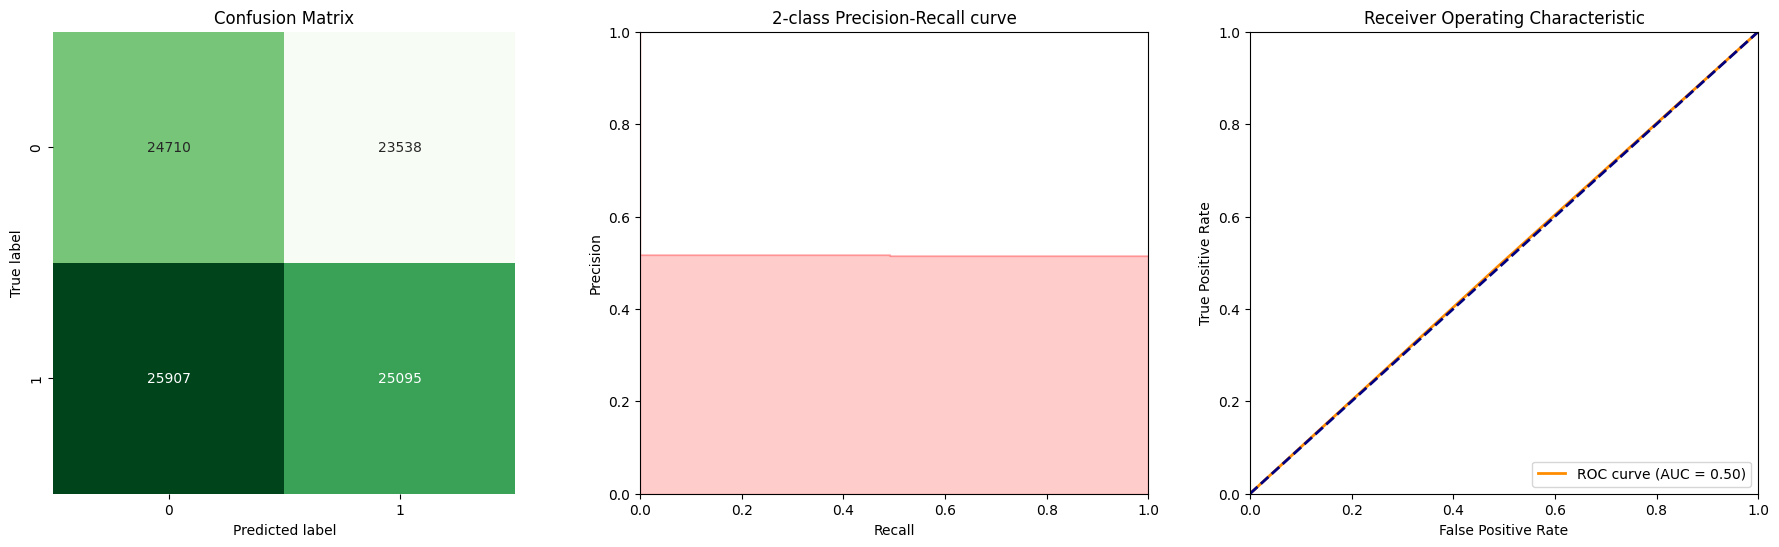

CPU times: user 6min 36s, sys: 18.9 s, total: 6min 55s
Wall time: 1min 12s


In [5]:
%%time

# Import libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)



#df_daily_data = pd.read_csv('transformed_daily_data/daily_data_5y_30k_features1.csv')

#df_model = df_daily_data.copy()



# Load dataset
df_model = pd.read_csv('transformed_daily_data/daily_data_5y_30k_features1.csv')


# Ensure datetime formatting
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

# Sort before creating shifted target
df_model = df_model.sort_values(['ticker', 'timestamp']).copy()

# Create target: whether next trading day's close is higher
df_model['next_close'] = df_model.groupby('ticker')['close'].shift(-1)
df_model['target'] = (df_model['next_close'] > df_model['close']).astype(int)

# Remove final row per ticker where next_close does not exist
df_model = df_model[df_model['next_close'].notna()].copy()

# Train: 2021-2024
train_df = df_model[
    (df_model['timestamp'] >= '2021-01-01') &
    (df_model['timestamp'] < '2025-01-01')
].copy()

# Test: 2025
test_df = df_model[
    (df_model['timestamp'] >= '2025-01-01') &
    (df_model['timestamp'] < '2026-01-01')
].copy()

# Columns to exclude from features
exclude_cols = [
    'timestamp',
    'ticker',
    'target',
    'next_close'
]

feature_cols = [col for col in df_model.columns if col not in exclude_cols]

X_train = train_df[feature_cols]
y_train = train_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']

model_rfc_daily_GSX_featmax = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

model_rfc_daily_GSX_featmax.fit(X_train, y_train)

y_pred = model_rfc_daily_GSX_featmax.predict(X_test)






def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of Positive instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [2PR / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()



# Build results dataframe
results_df = test_df.copy()

results_df['Prediction'] = y_pred
results_df['Prediction Correct'] = (
    results_df['target'] == results_df['Prediction']
).astype(int)

# Optional: include prediction probability/confidence
if hasattr(model_rfc_daily_GSX_featmax, "predict_proba"):
    y_pred_proba = model_rfc_daily_GSX_featmax.predict_proba(X_test)[:, 1]
    results_df['Prediction Probability'] = y_pred_proba
    results_df['Prediction Confidence'] = np.where(
        results_df['Prediction'] == 1,
        y_pred_proba,
        1 - y_pred_proba
    )

# Create output folders if they do not exist
results_path = 'models_daily_results/random_forest.csv'
model_path = 'models_daily/model_daily_rfc_GSX_featmax.joblib'

os.makedirs(os.path.dirname(results_path), exist_ok=True)
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save results and model
results_df.to_csv(results_path, index=False)
joblib.dump(model_rfc_daily_GSX_featmax, model_path)

# Print confirmations of saving
print(f"Results dataframe saved to: {results_path}")
print(f"Model saved to: {model_path}")

# Show summary report
show_summary_report(y_test, y_pred)